
# NLP Essentials Project

# Sentiment Analysis Online Movie Reviews

### Project Scenario

In a recent [market research](https://newsroom.ibm.com/IBMs-Global-AI-Adoption-Index-2021?lnk=ushpv18ai3) by IBM, almost one-third of IT professionals surveyed globally say their business is using Artificial Intelligence (AI). The survey reported almost half of businesses today are now using applications powered by natural language processing (NLP).

NLP, specifically 'Sentiment Analysis', can provide a key business advantage by abstracting from unstructured text data the negative or positive attitude of the writer/author. This crucuial insight can help turn web data into market intelligence for the business.

A request has been received from the web development department to add 'Sentiment Analysis' feature to a movie reviews page.

The insights from the sentiment analysis will be used to promote more popular movies.  

In this project, you are tasked to create a prototype NLP project that is capable of 'Sentiment Analysis' from movie reviews.

---


In this assignment, you will be working **individually** on the 'Sentiment Analysis' project.

Complete ALL THE TASKS ( From 1 to 7). You may refer to online documentation (e.g. keras, pandas, etc) for help on syntax.

`No copying of codes wholesale is allowed.`

Use a random_state = 42 where appropriate.

Broadly, this project will require the following steps:

1. Importing Various Modules.
2. Preparing The Data.

 2.1 Collect Relevant Data.

 2.2 Perform Image Preprocessing And Data Augementation.

 2.3 Split it into train, validate, and test datasets.

 2.4 Normalize The Data.


3. Create The Model - Build a model based on convolutional neural network.

4. Train The Model.

5. Evaluate The Model.

6. Visualizing Predictions On Validation Set.
 6.1 Plot The Learning Curve And Confusion Matrix.



# Part 1 : Data loading and preliminary inspection

The data for this project will be from `polarity dataset 2.0` collected by [Bo Pang and colleagues from Cornell Univeristy](http://www.cs.cornell.edu/people/pabo/movie-review-data/).

*(This dataset will be provided to you.)*

It was used for the paper published in 2002 called Thumbs up?
Sentiment Classification using Machine Learning Techniques, by Bo Pang, Lilian Lee, and Shivakumar Vaithyanathan.


Using google colab, load the given dataset according the folder structure.

In [835]:
path = r'C:\Users\L16 PRO\Downloads\ITE\NLP\Project\data\neg'
path2 = r'C:\Users\L16 PRO\Downloads\ITE\NLP\Project\data\pos'

### Folder Structure
**Reminder**

In your google drive folder ensure you have the following directory structure set up:
```
Directory Structure In Google Drive:
MyDrive
|
+-- ITE
     |
     +--NLP
        |
        +--Project
          |
          +data
              |
              +--pos
              |
              +--neg
         
```            


## Task 1: Data Collection

Collect an additional 30 samples of positive reviews and 30 samples of negative reviews from this website:
https://www.rottentomatoes.com/browse/movies_in_theaters/sort:newest?page=1


Add these to the given dataset respectively.

The final dataset should have 1000 positive reviews and 1000 negative reviews.


In [836]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


(-0.5, 1513.5, 1030.5, -0.5)

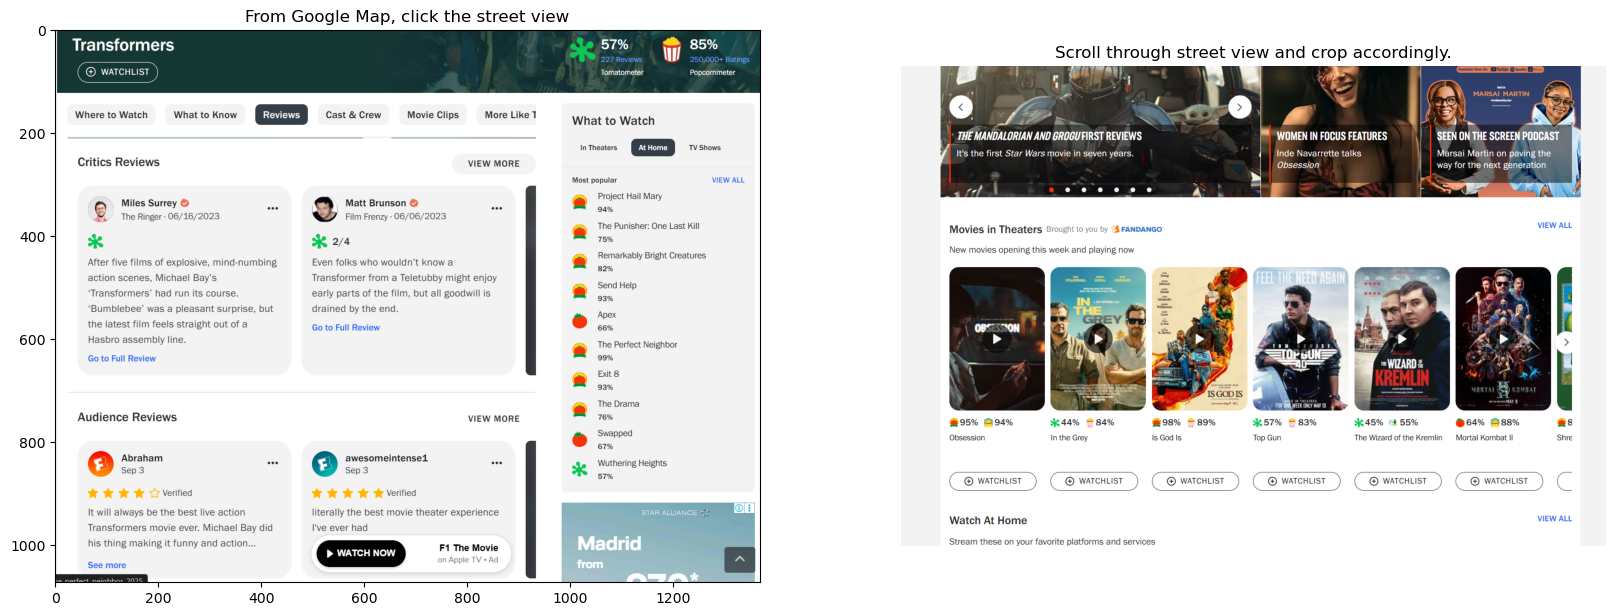

In [837]:
#@markdown { "tags": "hide-ouput" }

import matplotlib.pyplot as plt
f, ax=plt.subplots(1,2, figsize=(20,20))
pic_name1 = r"C:\Users\L16 PRO\Downloads\ITE\NLP\Project\ReviewsScreenCapture.png"
pic_name2=r"C:\Users\L16 PRO\Downloads\ITE\NLP\Project\MoviesPage.png"

ax[0].title.set_text("From Google Map, click the street view")
ax[0].imshow(plt.imread(pic_name1))

ax[1].title.set_text("Scroll through street view and crop accordingly.")
ax[1].imshow(plt.imread(pic_name2))
plt.axis('off')

In [838]:
# The following codes in this cell are provided as a guide.

import os

def read_in(folder):
    files = os.listdir(folder)
    a_dict = {}
    for a_file in sorted(files):
        if not a_file.startswith("."):
            with open(folder + a_file, encoding='ISO-8859-1', errors ='ignore') as f:
                file_id = a_file.split(".")[0].strip()
                a_dict[file_id] = f.read()
            f.close()
    return a_dict

Print out the number of reviews in positive and negative dictionaries, as well as the very first positive and very first negative reviews in the dictionaries.

In [839]:
import os

def read_in(folder):
    files = os.listdir(folder)
    a_dict = {}
    for a_file in sorted(files):
        if not a_file.startswith("."):
            with open(os.path.join(folder, a_file), encoding="utf-8") as f:
                a_dict[a_file] = f.read()
    return a_dict

# Absolute path to your data folder
folder = r"C:\Users\L16 PRO\Downloads\ITE\NLP\Project\data"

# Positive reviews
pos_dict = read_in(os.path.join(folder, "pos"))
sample_pos = pos_dict.get(next(iter(pos_dict)))

print("Number of Positive Reviews:", len(pos_dict))
print("Sample Positive Review:")
print(sample_pos[:300])

# Negative reviews
neg_dict = read_in(os.path.join(folder, "neg"))
sample_neg = neg_dict.get(next(iter(neg_dict)))

print("Number of Negative Reviews:", len(neg_dict))
print("Sample Negative Review:")
print(sample_neg[:300])


Number of Positive Reviews: 1000
Sample Positive Review:
films adapted from comic books have had plenty of success , whether they're about superheroes ( batman , superman , spawn ) , or geared toward kids ( casper ) or the arthouse crowd ( ghost world ) , but there's never really been a comic book like from hell before . 
for starters , it was created by 
Number of Negative Reviews: 1001
Sample Negative Review:
plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . 
what's the deal ? 
watch the movie and " sorta " find out . . . 
critique : a mind-fuck movie for the


## Task 2: Data Cleansing

Import the relevant NLTK libraries.

In [840]:
pip install nltk

In [841]:
# The following codes in this cell are provided as a guide

import nltk
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to C:\Users\L16
[nltk_data]     PRO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\L16
[nltk_data]     PRO\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\L16
[nltk_data]     PRO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\L16
[nltk_data]     PRO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

### Task 2.1 : Add More Stops Words To NLTK

Add the following to stopwords:
1. '@'
2. '#'
3. 'http'
4. ':'

In [842]:
stop = nltk.corpus.stopwords.words('english')
# Add a few more stop words we would like to remove here
##Complete the code below##
stop.extend(['@', '#', 'http', ':'])
stop

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

### Task 2.1 : Process Text - Tokenize, Remove Punctuation, Lemmatize

Complete the following functions.

In [843]:
import string

# tokenize text using nltk.
def tokenize(text):
  ##Complete the code below##
  return nltk.word_tokenize(text)

#remove punctuation from text using 'string.punctation'
def remove_punctuation(text):
  ##Complete the code below##
  cleaned = []
  for word in text:
     if word not in string.punctuation:
        cleaned.append(word)
  return cleaned

#lemmatize sentence using 'nltk.stem.PorterStemmer'
##Complete the code below##
def lemmatize(sentence):
    porter = nltk.stem.PorterStemmer()
    ##Complete the code below##
    stemmed = []
    for word in sentence:
        stemmed.append(porter.stem(word))
    return stemmed



def process_text(text):
    tokenized_text=tokenize(text)
    tokenized_text=remove_punctuation(tokenized_text)
    lemmas=lemmatize(tokenized_text)
    processed = [w.lower() for w in lemmas if w not in stop]
    return processed


In [844]:
test_review = "The movie was absolutely amazing! I loved it."
print(process_text(test_review))

['movi', 'wa', 'absolut', 'amaz', 'love']


## Task 3: Randomly Combine Review Texts From Positive & Negative Reviews Data Sets.

Preprocessed texts to remove punctuation, remove stop words andlemmatized the text.

Combine all these texts into a single dataset where each preprocessed review and its label are in a tuple:

`data=[('preprocessed review text', label), ('preprocessed review text', label) ...]`

**Example:**

* ('this movie is nice', 1)
* ('this movie is lousy',0)

Label for positive and negative review:
* `Positive review is given 1.`
* `Negative review is given 0.`


In [ ]:
import random
from tqdm import tqdm
def prepare_data(pos_dict, neg_dict):
    data=[]
    originalText=[]

    for each_dict in [pos_dict, neg_dict]:
    ##Complete the code below##.
        if each_dict == pos_dict:
            label = 1 # = 1 positive review
        else:
            label = 0 # = 0 negative review
        for id in tqdm(each_dict,desc='Reviews Progressed Bar'):
            ##Complete the code below##.
            text = each_dict[id]
            originalText.append(text)
            processed = process_text(text)
            data.append((' '.join(processed), label))


    random.seed(42)
    random.shuffle(data)
    texts = []
    labels = []
    for item in data:
        texts.append(item[0])
        labels.append(item[1])
    return originalText,texts, labels

originalText,texts, labels = prepare_data(pos_dict, neg_dict)

print(len(texts), len(labels))
print(texts[0])

Reviews Progressed Bar:   0%|          | 0/1000 [00:00<?, ?it/s]

Reviews Progressed Bar:  47%|████▋     | 469/1001 [00:07<00:08, 61.11it/s]

### Task 3.1 Split Dataset Into Train Test Sets.

Split the texts into:

1. 80% for training.
2. 20% for testing.

In [ ]:
def split(texts, labels, proportion):
    train_data = []
    train_targets = []
    test_data = []
    test_targets = []
    ##Complete the code below##
    split_index = int(len(texts) * proportion)
    for i in range(len(texts)):
        if i < split_index:
            train_data.append(texts[i])
            train_targets.append(labels[i])
        else:
            test_data.append(texts[i])
            test_targets.append(labels[i])

    return train_data, train_targets, test_data, test_targets

train_data, train_targets, test_data, test_targets = split(texts, labels, 0.8)

print(len(train_data)) # 1600?
print(len(train_targets)) # 1600?
print(len(test_data)) # 400?
print(len(test_targets)) # 400?
print(train_targets[:10]) # print out the targets for the first 10 training reviews
print(test_targets[:10]) # print out the targets for the first 10 test reviews

1600
1600
400
400
[1, 0, 1, 1, 0, 0, 0, 0, 1, 0]
[0, 1, 1, 0, 0, 1, 0, 1, 1, 1]


In [ ]:
%pip install scikit-learn

In [ ]:
# The following codes in this cell are provided as a guide

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer

In [ ]:
# The following codes in this cell are provided as a guide

count_vect = CountVectorizer(analyzer = "word", strip_accents=None, tokenizer = None, \
                             preprocessor = None, stop_words = None, max_features = 500)


train_data_features = count_vect.fit_transform(train_data)
test_data_features = count_vect.transform(test_data)

# Check the dimensionality
print(train_data_features.shape)
print(test_data_features.shape)


(1600, 500)
(400, 500)


The max features for CountVectorizer function has been set to 500. The parameter can be adjusted to improve results.

In [ ]:
print(train_data_features[:11])

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 1128 stored elements and shape (11, 500)>
  Coords	Values
  (0, 201)	2
  (0, 156)	9
  (0, 185)	4
  (0, 422)	4
  (0, 106)	1
  (0, 356)	2
  (0, 224)	1
  (0, 54)	1
  (0, 46)	3
  (0, 428)	2
  (0, 82)	2
  (0, 16)	3
  (0, 42)	2
  (0, 376)	4
  (0, 65)	4
  (0, 370)	2
  (0, 280)	3
  (0, 215)	2
  (0, 196)	3
  (0, 364)	4
  (0, 5)	3
  (0, 7)	7
  (0, 132)	4
  (0, 441)	3
  (0, 101)	1
  :	:
  (10, 9)	1
  (10, 219)	1
  (10, 264)	1
  (10, 200)	2
  (10, 123)	1
  (10, 450)	1
  (10, 118)	1
  (10, 272)	1
  (10, 481)	2
  (10, 249)	1
  (10, 410)	1
  (10, 20)	1
  (10, 91)	2
  (10, 363)	1
  (10, 17)	4
  (10, 301)	1
  (10, 347)	1
  (10, 186)	1
  (10, 468)	1
  (10, 220)	1
  (10, 354)	1
  (10, 108)	2
  (10, 69)	1
  (10, 403)	1
  (10, 199)	1


In [ ]:
count_vect.get_feature_names_out()[321]

'play'

# Part 2: Perform AI Natural Language Inference

## Task 4: Feature Extraction Using TF-IDF

Perform normalization of bag of words using the TfidfTransformer. Use it the same way as above.

Create a class, and use the .fit_transform() method with the bag of words as your argument to create your TFIDF.


In [ ]:
tfidfier = TfidfTransformer()
tfidf = tfidfier.fit_transform(train_data_features)
tfidf_test = tfidfier.transform(test_data_features)

In [ ]:
print("Training features shape:", tfidf.shape)
print("Testing features shape:", tfidf_test.shape)

Training features shape: (1600, 500)
Testing features shape: (400, 500)


In [ ]:
# The following codes in this cell are provided as a guide

import numpy as np
X_train = tfidf.toarray()
y_train = np.array(train_targets.copy())
X_test = tfidf_test.toarray()
y_test = np.array(test_targets.copy())

In [ ]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# The following codes in this cell are provided as a guide
# Convert a vector with integers representing different categories
# into binary form: [0,1,0,0 ... ]
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
y_train=to_categorical(y_train-y_train.min())
y_test=to_categorical(y_test-y_test.min())

In [ ]:
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("Sample y_train:", y_train[:3])

y_train shape: (1600, 2)
y_test shape: (400, 2)
Sample y_train: [[0. 1.]
 [1. 0.]
 [0. 1.]]


In [ ]:
y_train[0]

array([0., 1.])

In [ ]:
np.unique(y_train[:,1], return_counts=True)

(array([0., 1.]), array([798, 802], dtype=int64))

In [ ]:
y_test[-10:]

array([[0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.]])

## Task 5: Create Model Using Neural Networks

Create a suitable neural network and train it.


In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Input   # Input is part of layers
from tensorflow.keras.optimizers import Adam
from keras.callbacks import EarlyStopping

# Build the model
model = Sequential([
    Input(shape=(500,)),                # Proper way to define input
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(2, activation='softmax')
])

# Compile with categorical crossentropy (for one-hot labels)
model.compile(loss='categorical_crossentropy',
              optimizer=Adam(learning_rate=0.001),
              metrics=['accuracy'])

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train
history = model.fit(X_train, y_train,
                    epochs=400,   # much lower than 1700
                    batch_size=32,
                    validation_data=(X_test, y_test),
                    callbacks=[early_stop],
                    verbose=1)

Epoch 1/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.6488 - loss: 0.6532 - val_accuracy: 0.7500 - val_loss: 0.5800
Epoch 2/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8225 - loss: 0.4442 - val_accuracy: 0.7850 - val_loss: 0.4365
Epoch 3/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8694 - loss: 0.3125 - val_accuracy: 0.8200 - val_loss: 0.4181
Epoch 4/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9112 - loss: 0.2444 - val_accuracy: 0.8100 - val_loss: 0.4409
Epoch 5/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9256 - loss: 0.1975 - val_accuracy: 0.7875 - val_loss: 0.4912
Epoch 6/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9575 - loss: 0.1414 - val_accuracy: 0.8075 - val_loss: 0.5251
Epoch 7/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9762 - loss: 0.0961 - val_accuracy: 0.7875 - val_loss: 0.5800
Epoch 8/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9925 - loss: 0.0539 - val_accuracy: 0.7900 -

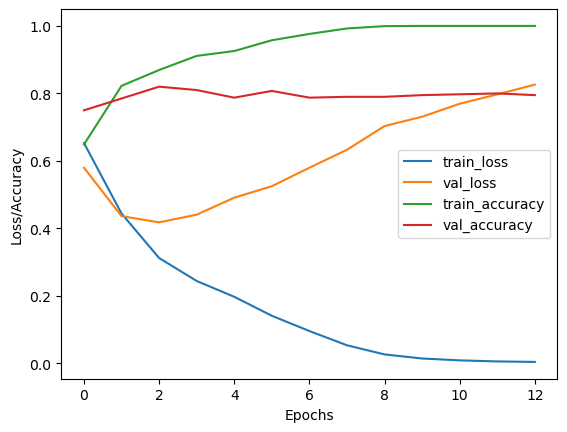

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_graphs(H):
    # Use the actual number of epochs recorded
    num_epochs = len(H.history["loss"])
    plt.plot(np.arange(0, num_epochs), H.history["loss"], label="train_loss")
    plt.plot(np.arange(0, num_epochs), H.history["val_loss"], label="val_loss")
    plt.plot(np.arange(0, num_epochs), H.history["accuracy"], label="train_accuracy")
    plt.plot(np.arange(0, num_epochs), H.history["val_accuracy"], label="val_accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Loss/Accuracy")
    plt.legend()
    plt.show()

# Call with just the history object
plot_graphs(history)

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

predicted = model.predict(X_test)
predicted_label=[np.argmax(each) for each in np.array(predicted)]
y_test_label=[np.argmax(each) for each in np.array(y_test)]
print("\nConfusion matrix:")
print(confusion_matrix(y_test_label, predicted_label))
print(classification_report(y_test_label, predicted_label))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

Confusion matrix:
[[168  34]
 [ 38 160]]
              precision    recall  f1-score   support

           0       0.82      0.83      0.82       202
           1       0.82      0.81      0.82       198

    accuracy                           0.82       400
   macro avg       0.82      0.82      0.82       400
weighted avg       0.82      0.82      0.82       400



## Task 6: Test For Unseen Text

Use the trained model to make predictions on totally unseen text.

In [ ]:
#use the following text for prediction
neg_text="Just when you think you’ve seen the worst movie ever made,\
along comes this pile of toxic waste."

pos_text="This is going to go down as one of 2022’s most entertaining motion pictures."


In [ ]:
def test_model(pos_text,neg_text,count_vect,tfidfier, model):
  for text in [pos_text,neg_text]:

    processed_NewText=' '.join(process_text(text))

    print("\nNew Text To Predict:\n","\""+text+"\"")
    # Step 1 - CountVectorizer first, then TF-IDF
    count_features = count_vect.transform([processed_NewText])
    text_for_prediction=tfidfier.transform(count_features)

    result=model.predict(text_for_prediction.toarray())

    if np.argmax(result) == 0:
      print()
      print("Predicted Sentiment: NEGATIVE")
    else:
      print()
      print("Predicted Sentiment: POSITIVE")

test_model(pos_text,neg_text,count_vect,tfidfier, model)


New Text To Predict:
 "This is going to go down as one of 2022’s most entertaining motion pictures."
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

Predicted Sentiment: POSITIVE

New Text To Predict:
 "Just when you think you’ve seen the worst movie ever made,along comes this pile of toxic waste."
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step

Predicted Sentiment: NEGATIVE


## Task 7: Apply Cosine Similarity To Find Similar Texts

Based on the given unseen positive and negative text previously, find the top most similar sentences from the training dataset.

Reminder: Please note that you have to use the same fitted "tfidf" model to perform feature extraction of your texts.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

neg_text="Just when you think you’ve seen the worst movie ever made, along comes this pile of toxic waste."

pos_text="This is going to go down as one of 2022’s most entertaining motion pictures."

def findSimiarlTextModel(pos_text,neg_text,count_vect,tfidfier, model):
  for text in [pos_text,neg_text]:

    processed_NewText=' '.join(process_text(text))

    print("\nNew Text To Predict:\n","\""+text+"\"")

    # Convert new text to TF-IDF vector
    count_features = count_vect.transform([processed_NewText])
    text_for_prediction=tfidfier.transform(count_features).toarray()

    # Compare against all training reviews
    vals=cosine_similarity(text_for_prediction, X_train)
    vals=vals.reshape(-1)


    print(vals, type(vals), vals.shape)
    print(vals.argsort()[-1])
    print(vals[vals.argsort()[-1]])
    print(originalText[vals.argsort()[-1]])

findSimiarlTextModel(pos_text,neg_text,count_vect,tfidfier, model)


New Text To Predict:
 "This is going to go down as one of 2022’s most entertaining motion pictures."
[0.07562409 0.06441693 0.1024852  ... 0.0351052  0.01802886 0.07187903] <class 'numpy.ndarray'> (1600,)
703
0.4926859717000642
the characters in " palmetto " collectively sweat enough to fill lake erie , and it's just the right way to capture the film's ripe atmosphere of sensuality , tension and even farce . 
this humid florida-set thriller nurtures a modestly absurd edginess that often winks at itself , which is very much a good thing since the actors and director are in on the joke . 
as far as set-up is concerned , the movie is nothing we haven't seen before , but be patient -- " palmetto " spins some pretty wicked story twists that we really don't see coming . 
it's not a classic by any means , but it sure is quite an engaging surprise . 
harry barber ( woody harrelson ) is fresh out of prison , where he's served a couple of years for a crime he didn't commit . 
even though he har

---

**End of Project**

---